In [1]:
import tensorflow as tf 
from tensorflow import keras 
import matplotlib.pyplot as plt 
%matplotlib inline 

In [2]:
(x_train,y_train),(x_test,y_test) = keras.datasets.cifar10.load_data() 

In [3]:
x_train.shape 

(50000, 32, 32, 3)

In [4]:
x_train[0] 

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0 

# Using Artificial Neural Network(ANN) for classification

In [6]:
from tensorflow.keras import models, layers 
ann = models.Sequential([ 
        layers.Flatten(input_shape=(32,32,3)), # flatten - converting multi-dimensional data into a 1D-dimensional array.
        layers.Dense(3000, activation='relu'), # input shape = (32,32,3) , whre 32*32 is height & width and 3 is no of colour chaneels like RBG
        layers.Dense(1000, activation='relu'),  # dense - hidden layer contaims 3000 neurons
        layers.Dense(10, activation='softmax')    # relu - Value Range: [0,∞)

ann.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',# it is loss function
              metrics=['accuracy'])

ann.fit(x_train, y_train, epochs=5) 

C:\Users\akhil\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 288s 182ms/step - accuracy: 0.3284 - loss: 1.8977
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 292s 187ms/step - accuracy: 0.4035 - loss: 1.6577
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 318s 184ms/step - accuracy: 0.4348 - loss: 1.5789
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 308s 197ms/step - accuracy: 0.4509 - loss: 1.5307
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 324s 207ms/step - accuracy: 0.4642 - loss: 1.4934


In [7]:
model.evaluate(x_test,y_test)

NameError: name 'model' is not defined

# using CNN for classiifcation

In [8]:
from tensorflow.keras import models, layers
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D((2,2)))
#model.add(layers.Dropout(0.2))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.Flatten()) 
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))


model.compile(optimizer = 'adam',
              metrics = ['accuracy'],
              loss='sparse_categorical_crossentropy'
             )
model.fit(x_train,y_train,epochs=20,batch_size= 128) # batch_size - updates the weights for every 64(value) images ,based on the value we took

C:\Users\akhil\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 66ms/step - accuracy: 0.3876 - loss: 1.6655
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 30s 77ms/step - accuracy: 0.5222 - loss: 1.3251
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 98ms/step - accuracy: 0.5818 - loss: 1.1763
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 44s 105ms/step - accuracy: 0.6164 - loss: 1.0900
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 69s 71ms/step - accuracy: 0.6476 - loss: 1.0050
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.6700 - loss: 0.9505
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.6866 - loss: 0.9056
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.7003 - loss: 0.8644
Epoch 9/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 38s 76ms/step - accuracy: 0.7161 - loss: 0.8205
Epoch 10/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 85ms/step - accuracy: 0.7257 - loss: 0.7905 
Epoch 11/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 34s 87ms/step - accuracy: 0.7337 - loss: 0.7653
Epoch 12/20
391/391 ━━━━━━━━

In [9]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7166 - loss: 0.8651


[0.8651238083839417, 0.7166000008583069]

In [10]:
pred = model.predict(x_test) 

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


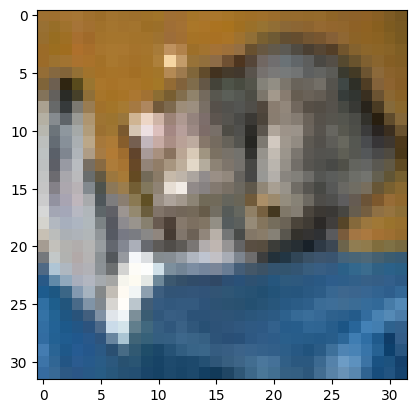

In [11]:
plt.imshow(x_test[0])
plt.show() 

In [12]:
maxv = float(np.max(pred[0])) 
print(maxv) # Get the index of the maximum value in the first row(pred[0]) 


NameError: name 'np' is not defined

In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU') 
